In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
data = pd.read_csv('лр3.csv', sep=",")
# Первые 5 строк датасета
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# проверим есть ли пропущенные значения
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
from sklearn.preprocessing import LabelEncoder
cat_enc = pd.DataFrame({'c1':data.T[0]})
cat_enc

,c1
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest
charges,16884.924


In [7]:
le_sex = LabelEncoder()
data['sex_kod'] = le_sex.fit_transform(data['sex'])
data.head()

,age,sex,bmi,children,smoker,region,charges,sex_kod
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1


In [8]:
le_smoker = LabelEncoder()
data['smoker_kod'] = le_smoker.fit_transform(data['smoker'])
data.head()

,age,sex,bmi,children,smoker,region,charges,sex_kod,smoker_kod
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0


In [9]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
region_encoded = ohe.fit_transform(data[['region']])

region_cols = [f'region_{cat}' for cat in ohe.categories_[0][1:]]
region_data = pd.DataFrame(region_encoded, columns=region_cols)

data = data.drop('region', axis=1)
data = pd.concat([data, region_data], axis=1)

data = data.drop(['sex', 'smoker'], axis=1)

data = data.rename(columns={
    'sex_kod': 'sex',
    'smoker_kod': 'smoker'
})

data.head()

,age,bmi,children,charges,sex,smoker,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1,0,1.0,0.0,0.0


In [10]:
from sklearn.model_selection import train_test_split

# Признаки (X) и целевая переменная (y)
X = data[['age', 'bmi', 'children', 'sex', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']]
y = data['charges']

# Разделение: 80% обучение, 20% тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% на тест
    random_state=42         # фиксируем random seed для воспроизводимости
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 1070 строк
Тестовая выборка: 268 строк


In [11]:
!pip install gmdhpy
from gmdhpy.gmdh import MultilayerGMDH, RefFunctionType

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

def val_mae(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = mean_absolute_error(y_test, y_pred)
    print(model.__class__.__name__)
    print('MAE = {:.2f}'.format(result))
    return result

print("="*50)
print("Оценка отдельных моделей (как в методичке)")
print("="*50)
results_mae = {}

for model in [
    LinearRegression(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(n_estimators=50, random_state=42)
]:
    mae = val_mae(model)
    results_mae[model.__class__.__name__] = mae

Оценка отдельных моделей (как в методичке)
LinearRegression
MAE = 4181.19
DecisionTreeRegressor
MAE = 3195.11
RandomForestRegressor
MAE = 2553.09


In [17]:
# Эксперимент 1
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: линейная регрессия
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

base_models = [
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

meta_model = LinearRegression()

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=10
)


stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)
mae_stack = mean_absolute_error(y_test, y_pred_stack)

print(f"StackingRegressor MAE = {mae_stack:.2f}")

# Сравнение с лучшей базовой моделью
print(f"Улучшение относительно RandomForest: {results_mae['RandomForestRegressor'] - mae_stack:.2f}")

StackingRegressor MAE = 2469.67
Улучшение относительно RandomForest: 83.42


In [19]:
# Эксперимент 2
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: случайный лес
from sklearn.ensemble import RandomForestRegressor

# Базовые модели
base_models_exp2 = [
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

# Мета-модель - СЛУЧАЙНЫЙ ЛЕС
meta_model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

stacking_model_rf = StackingRegressor(
    estimators=base_models_exp2,
    final_estimator=meta_model_rf,
    cv=10
)

stacking_model_rf.fit(X_train, y_train)
y_pred_stack_rf = stacking_model_rf.predict(X_test)
mae_stack_rf = mean_absolute_error(y_test, y_pred_stack_rf)

print(f"Stacking (мета-модель = RandomForest) MAE = {mae_stack_rf:.2f}")

Stacking (мета-модель = RandomForest) MAE = 2485.55


In [20]:
# Эксперимент 3
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: линейная регрессия
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Три базовые модели
base_models_exp3 = [
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

# Мета-модель - LinearRegression
meta_model_lr = LinearRegression()


stacking_3models = StackingRegressor(
    estimators=base_models_exp3,
    final_estimator=meta_model_lr,
    cv=10
)

stacking_3models.fit(X_train, y_train)
y_pred_stack_3 = stacking_3models.predict(X_test)
mae_stack_3 = mean_absolute_error(y_test, y_pred_stack_3)

print(f"Stacking (3 базовые модели, мета=LinearRegression) MAE = {mae_stack_3:.2f}")

Stacking (3 базовые модели, мета=LinearRegression) MAE = 2469.67


In [21]:
# Эксперимент 4
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: случайный лес
from sklearn.ensemble import RandomForestRegressor

# Три базовые модели
base_models_exp4 = [
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

# Мета-модель - RandomForest
meta_model_rf_2 = RandomForestRegressor(n_estimators=100, random_state=42)

stacking_exp4 = StackingRegressor(
    estimators=base_models_exp4,
    final_estimator=meta_model_rf_2,
    cv=10
)
stacking_exp4.fit(X_train, y_train)
y_pred_stack_4 = stacking_exp4.predict(X_test)
mae_stack_4 = mean_absolute_error(y_test, y_pred_stack_4)

print(f"Stacking (3 модели → RandomForest) MAE = {mae_stack_4:.2f}")

Stacking (3 модели → RandomForest) MAE = 2485.55


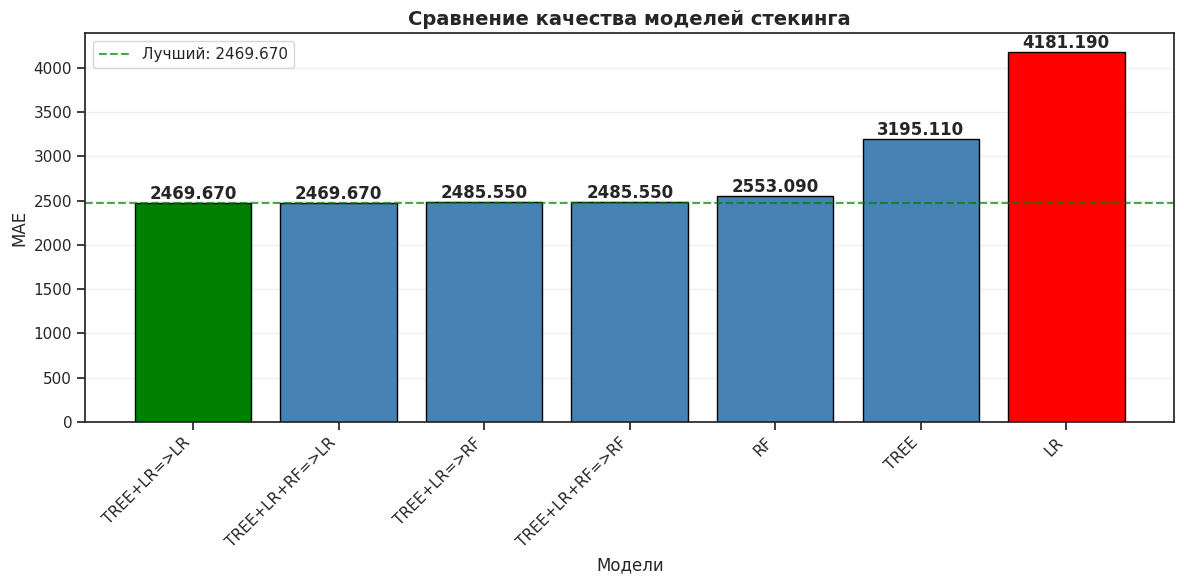

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Ваши данные
array_labels = ['LR', 'TREE', 'RF', 'TREE+LR=>LR',
                'TREE+LR=>RF', 'TREE+LR+RF=>LR', 'TREE+LR+RF=>RF']
array_mae = [4181.19, 3195.11, 2553.09,
             2469.67, 2485.55, 2469.67,
             2485.55]

# Сортировка
sorted_indices = np.argsort(array_mae)
sorted_mae = [array_mae[i] for i in sorted_indices]
sorted_labels = [array_labels[i] for i in sorted_indices]

# Визуализация
plt.figure(figsize=(12, 6))
colors = ['green' if i == 0 else 'red' if i == len(sorted_mae)-1 else 'steelblue'
          for i in range(len(sorted_mae))]
bars = plt.bar(range(len(sorted_mae)), sorted_mae, color=colors, edgecolor='black')

# Подписи значений
for bar, val in zip(bars, sorted_mae):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Модели', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Сравнение качества моделей стекинга', fontsize=14, fontweight='bold')
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Лучший результат
plt.axhline(y=min(array_mae), color='green', linestyle='--', alpha=0.7,
            label=f"Лучший: {min(array_mae):.3f}")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# MLP
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
#нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

print("РЕЗУЛЬТАТ MLP")
print(f"MAE = {mae_mlp:.2f}")

РЕЗУЛЬТАТ MLP
MAE = 4018.80
